## Focus on 'congenital heart disease' network
* CHD genes are defined from this website: https://chdgene.victorchang.edu.au/
* There are 142 genes 

In [1]:
!date +%F

2025-02-27


In [2]:
#!/usr/bin/env python3
import os
import re
import sys
print(sys.executable)
print(sys.path)
print(sys.version)
import pickle

import random
from itertools import combinations
import matplotlib
import glob
import math
%matplotlib inline
import matplotlib.gridspec as gridspec
import networkx as nx
import gseapy as gp
import scipy.io
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'pdf.fonttype':42}) 

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
import scipy.sparse as sp_sparse

from tqdm import tqdm
print('numpy', np.__version__)
print('pandas', pd.__version__)
print('scipy', scipy.__version__)
print('matplotlib', matplotlib.__version__)

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/bin/python
['/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python312.zip', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/lib-dynload', '', '/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages']
3.12.2 | packaged by conda-forge | (main, Feb 16 2024, 20:50:58) [GCC 12.3.0]
numpy 1.26.4
pandas 2.2.1
scipy 1.12.0
matplotlib 3.8.3


### Load disease gene data  

In [3]:
CHD_genes_df = pd.read_csv('/project/GCRB/Hon_lab/s426305/Analysis/IGVF/OpenTarget/CHD_Yang/chdgene_table.csv', sep=',')

In [4]:
CHD_gene_name = CHD_genes_df["Gene"].values

In [5]:
CHD_gene_name.shape

(142,)

### Load pySpade data

In [6]:
global_df = pd.read_csv('/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/Manhattan_plots/filtered_df.csv')

In [7]:
#Load annotation file 
annot_dict_file = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/annotation_dict_hg38.txt'
annot_dict = {}
with open(annot_dict_file) as f:
    for line in f:
        region_id, annotation = line.strip().split("\t")
        annot_dict.update({region_id : annotation})

In [8]:
TF_region_df = pd.DataFrame.from_dict(annot_dict, columns=['TF'], orient='index')

### Find out any targeted TFs that are CHD genes

In [9]:
CHD_TF = list(set(TF_region_df['TF'].values).intersection(CHD_genes_df['Gene']))

In [10]:
CHD_TF

['FOXC2',
 'TFAP2B',
 'SMARCA4',
 'ARID1A',
 'GATA5',
 'KMT2A',
 'SON',
 'FOXC1',
 'NKX2-5',
 'NOTCH2',
 'NKX2-6',
 'NF1',
 'MAP3K7',
 'PRDM6',
 'NONO',
 'TBX20',
 'PITX2',
 'SALL4',
 'SMAD2',
 'FOXH1',
 'SMARCB1',
 'MEIS2',
 'NOTCH1',
 'AFF4',
 'EP300',
 'SMAD4',
 'SMAD6',
 'SALL1',
 'ZIC3',
 'FOXP1',
 'HAND1',
 'TBX5',
 'HAND2',
 'MESP1',
 'LZTR1',
 'GATA6',
 'RERE',
 'ZEB2',
 'KDM2B',
 'CHD7',
 'HNRNPK',
 'PBX1',
 'GLI3',
 'GATA4',
 'SMAD3',
 'ARID1B',
 'ZFPM2',
 'NR2F2',
 'TBX1',
 'CREBBP']

In [11]:
len(CHD_TF)

50

In [12]:
CHD_TF_region = list(TF_region_df[TF_region_df['TF'].isin(CHD_TF)].index)

In [13]:
gene_counts = global_df[global_df['region'].isin(CHD_TF_region)]['gene_names'].value_counts()
duplicate_genes = gene_counts[gene_counts > 4].index
CHD_TF_global_df = global_df[global_df['region'].isin(CHD_TF_region)][global_df[global_df['region'].isin(CHD_TF_region)]['gene_names'].isin(duplicate_genes)]

### Generate the gene regulatory networks

In [14]:
global_df

,Unnamed: 0,idx,gene_names,chromosome,pos,strand,color_idx,chr_idx,region,num_cell,bin,log(pval)-hypergeom,fc,Significance_score,fc_by_rand_dist_cpm,pval-empirical,cpm_perturb,cpm_bg
0,842,5634,NCOA1,chr2,273448336,+,1,1,chr2:24491867-24491918,1095,1000,-32.016317,0.475990,-29.364714,0.475884,0.0,36.466845,76.640684
1,8539,5766,TOGARAM2,chr2,277913033,+,1,1,chr2:24491867-24491918,1095,1000,-8.652957,4.362876,-13.826488,4.201964,0.0,1.933531,0.452529
2,9304,11184,ATP2C1,chr3,622000546,+,0,2,chr2:24491867-24491918,1095,1000,-12.539143,1.273239,-12.935412,1.266945,0.0,72.131064,56.930946
3,11197,27033,AUH,chr9,1627850825,-,0,8,chr2:24491867-24491918,1095,1000,-12.038827,1.211893,-11.423718,1.215758,0.0,106.607830,87.686569
4,12352,35685,ANO4,chr12,2044485199,+,1,11,chr2:24491867-24491918,1095,1000,-9.896326,1.517444,-10.746372,1.501914,0.0,17.795341,11.845102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27573,31558319,38228,FITM1,chr14,2215538585,+,1,13,chrX:49042845-49043845,794,750,-12.332692,1.287023,-13.735282,1.285053,0.0,135.824176,105.693160
27574,31559427,47101,PECAM1,chr17,2555194338,-,0,16,chrX:49042845-49043845,794,750,-9.699542,16.178142,-11.238323,14.979639,0.0,3.247754,0.207479
27575,31579300,28022,DPP7,chr9,1673604089,-,0,8,chr19:52527153-52528153,811,750,-19.835936,0.714110,-19.482662,0.715293,0.0,186.828915,261.196259
27576,31582291,51353,ZNF808,chr19,2706938940,+,0,18,chr19:52527153-52528153,811,750,-18.799928,0.471482,-18.062261,0.474419,0.0,17.071369,35.994817


In [15]:
target_region_list = np.unique(global_df["region"])

In [16]:
min_regulating_gene = 3

G = nx.DiGraph()

valid_tf_region_list = []
local_hit_list = []
global_hit_list = []
skip_list = []
deg_num_list = []

for target_region in tqdm(target_region_list):
    primary_gene = annot_dict[target_region]
    secondary_target_list = list(set(global_df[global_df['region'] == target_region]["gene_names"].values))

    if (re.search("^OR[0-9]",primary_gene) != None) or \
       (primary_gene == 'NonTarget'):
        skip_list.append(primary_gene)
        continue

    if (len(secondary_target_list) < min_regulating_gene):
        skip_list.append(primary_gene)
        continue
    valid_tf_region_list.append(target_region)
    G.add_node(primary_gene, type='TF', color=0, subset=0) 

print("Valid TFs",len(list(G.nodes())))

for target_region in tqdm(valid_tf_region_list):
    primary_gene = annot_dict[target_region]

    secondary_target_list = list(set(global_df[global_df['region'] == target_region]["gene_names"].values))
    secondary_fc_list = list(set(global_df[global_df['region'] == target_region]["fc_by_rand_dist_cpm"].values))
    deg_num_list.append(len(secondary_target_list))
    for secondary_target,secondary_fc in zip(secondary_target_list,secondary_fc_list):
        global_hit_list.append(secondary_target)
        if not secondary_target in list(G.nodes()):
            G.add_node(secondary_target, type='gene', color=1, subset=2)
        
        if (primary_gene == secondary_target):
            continue
        if secondary_fc > 1:
            G.add_edge(primary_gene, secondary_target, regulation='up_regualte')
        else:
            G.add_edge(primary_gene, secondary_target, regulation='down_regualte')


100%|██████████| 2082/2082 [00:02<00:00, 723.63it/s]


Valid TFs 1323


100%|██████████| 1397/1397 [00:05<00:00, 252.48it/s]


In [17]:
TF_region_df[TF_region_df["TF"]=="TBX5"]

,TF
chr12:114405669-114406173,TBX5
chr12:114407720-114407979,TBX5


In [18]:
global_df[global_df["region"]=="chr12:114405669-114406173"]

,Unnamed: 0,idx,gene_names,chromosome,pos,strand,color_idx,chr_idx,region,num_cell,bin,log(pval)-hypergeom,fc,Significance_score,fc_by_rand_dist_cpm,pval-empirical,cpm_perturb,cpm_bg
13117,10456907,5927,SLC8A1,chr2,289567475,-,1,1,chr12:114405669-114406173,279,500,-14.153573,0.780264,-13.742050,0.778913,0.0,1575.097251,2022.176842
13118,10456926,6083,NRXN1,chr2,300181997,-,1,1,chr12:114405669-114406173,279,500,-12.331129,0.378570,-11.317575,0.379919,0.0,21.980393,57.871761
13119,10457134,7942,KCNH7,chr2,411795152,-,1,1,chr12:114405669-114406173,279,500,-15.415384,0.622149,-14.017528,0.620823,0.0,367.999299,592.766469
13120,10457344,9523,PLCL2,chr3,507952602,+,0,2,chr12:114405669-114406173,279,500,-12.295756,0.475812,-11.421372,0.471073,0.0,58.214552,123.589741
13121,10457569,11164,TRH,chr3,621124256,+,0,2,chr12:114405669-114406173,279,500,-20.429671,0.363913,-20.450777,0.363011,0.0,61.656285,169.864496
13122,10457802,13158,TECRL,chr4,753854978,-,1,3,chr12:114405669-114406173,279,500,-29.564719,0.547234,-24.326861,0.546737,0.0,429.014184,784.690074
13123,10458105,16341,NREP,chr5,991657529,-,0,4,chr12:114405669-114406173,279,500,-12.964087,0.729081,-12.967184,0.727601,0.0,467.043218,641.898445
13124,10458641,20418,QKI,chr6,1224612324,+,1,5,chr12:114405669-114406173,279,500,-12.372684,0.701782,-11.088291,0.701243,0.0,333.102433,475.021290
13125,10459015,24265,SFRP1,chr8,1432659773,-,1,7,chr12:114405669-114406173,279,500,-10.748751,0.608985,-10.547360,0.609925,0.0,214.566451,351.797909
13126,10459411,27936,CAMSAP1,chr9,1672396140,-,0,8,chr12:114405669-114406173,279,500,-11.845288,0.212490,-11.521048,0.214310,0.0,4.973187,23.242274


In [19]:
for i,gene_list in enumerate(list(nx.weakly_connected_components(G))):
    print(i,len(gene_list))

0 8438
1 3
2 4
3 4
4 4
5 4
6 4
7 3


In [20]:
largest_subgraph_nodes = list(nx.weakly_connected_components(G))[0]
largest_subgraph = G.subgraph(largest_subgraph_nodes).copy()

In [21]:
# remove miscullas graph
G = largest_subgraph

In [22]:
print("Nodes",len(G.nodes()))
print("edges",len(G.edges()))

Nodes 8438
edges 25621


In [23]:
pickle.dump(G, open('GRN_base.pickle', 'wb'))

In [24]:
TF_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "TF"]
gene_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "gene"]

In [25]:
degree_freq = np.array(nx.degree_histogram(G))
degrees = np.array(range(len(degree_freq)))
degree_probabilities = np.array([f / float(sum(degree_freq)) for f in degree_freq])

exist_index = np.where(degree_freq!=0)
degrees = degrees[exist_index]
degree_probabilities = degree_probabilities[exist_index]

slope, intercept = np.polyfit(np.log(degrees[:50]), np.log(degree_probabilities[:50]), 1)
print(f"power law: {slope}")

power law: -2.0445682303044834


0.2930274044547856 9.84573501559995e-05


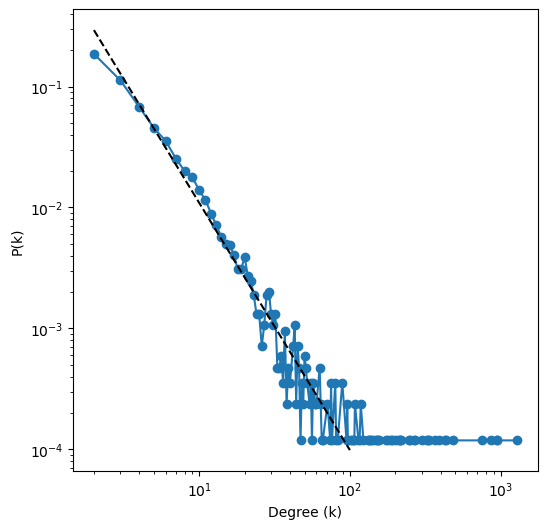

In [26]:
x1,x2 = 2,100
log_x = np.log10([x1,x2])
y1,y2 = np.power(10,log_x*slope+intercept)
print(y1,y2)

fg,ax=plt.subplots(figsize=(6,6))
plt.loglog(degrees[1:], degree_probabilities[1:], marker='o')
plt.loglog([x1,x2],[y1,y2],c="black",linestyle="--")
plt.xlabel("Degree (k)")
plt.ylabel("P(k)")
plt.savefig("./Plot/scale_figure.pdf")

### Analyze directed property on TF-TF network

In [27]:
def generate_TF_random_graph(G,between_TF_prb,TF_gene_prb):
    G_random = nx.Graph()    
    
    TF_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "TF"]
    gene_nodes = [node for node, data in G.nodes(data=True) if data.get("type") == "gene"]
    
    G_random.add_nodes_from(TF_nodes, type='TF', color=0, subset=0) 
    G_random.add_nodes_from(gene_nodes, type='gene', color=1, subset=2)
    
    #TF-TF nodes
    combis = combinations(TF_nodes,2)
    total_edges = []
    
    for tf_1,tf_2 in combis:
        if random.random() < between_TF_prb:
            total_edges.append([tf_1,tf_2])
    for TF_node in TF_nodes:
        for gene_node in gene_nodes:
            if random.random() < TF_gene_prb:
                total_edges.append([TF_node,gene_node])
    
    G_random.add_edges_from(total_edges)
    
    components = list(nx.connected_components(G_random))
    largest_component = max(components, key=len)
    G_random_sg = G_random.subgraph(largest_component).copy()
    
    return G_random_sg

def extract_TF_TF_graph(G):
    TF_node_list = [node for node, data in G.nodes(data=True) if data.get("type") == "TF"]
    TF_TF_network = G.subgraph(TF_node_list).copy()
    
    components = list(nx.weakly_connected_components(TF_TF_network))
    largest_component = max(components, key=len)
    TF_TF_sg = G.subgraph(largest_component).copy()
    
    return TF_TF_sg
    

In [28]:
TF_TF_rand_network = extract_TF_TF_graph(G)
print("Node:",len(TF_TF_rand_network.nodes))
print("Edge:",len(TF_TF_rand_network.edges))

Node: 716
Edge: 1536


In [29]:
in_degrees = dict(TF_TF_rand_network.in_degree())
out_degrees = dict(TF_TF_rand_network.out_degree())

in_degree_values = list(in_degrees.values())
out_degree_values = list(out_degrees.values())

in_degree_max = max(in_degree_values)
out_degree_max = max(out_degree_values)

In [30]:
in_degree_df = pd.DataFrame(in_degrees.values(),index=in_degrees.keys(),columns=["Count"])
out_degree_df = pd.DataFrame(out_degrees.values(),index=out_degrees.keys(),columns=["Count"])

In [31]:
out_degree_df.sort_values("Count",ascending=False)

,Count
ISL1,91
TBX20,62
TADA2B,57
SOX11,56
RCOR2,54
...,...
CREM,0
CBFA2T2,0
PPP1CB,0
SCAPER,0


In [32]:
in_degrees["ZNF441"]

0

<Axes: ylabel='Count'>

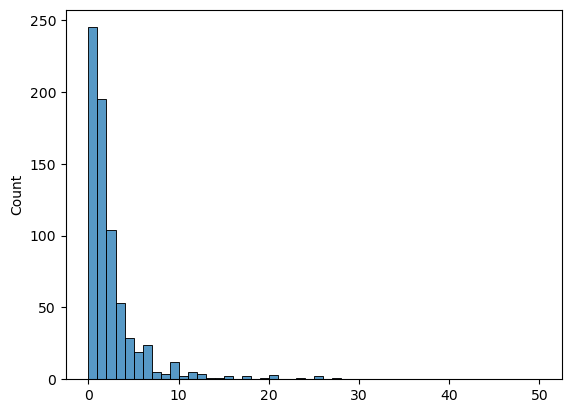

In [33]:
sns.histplot(in_degree_values,bins=range(in_degree_max))

<Axes: ylabel='Count'>

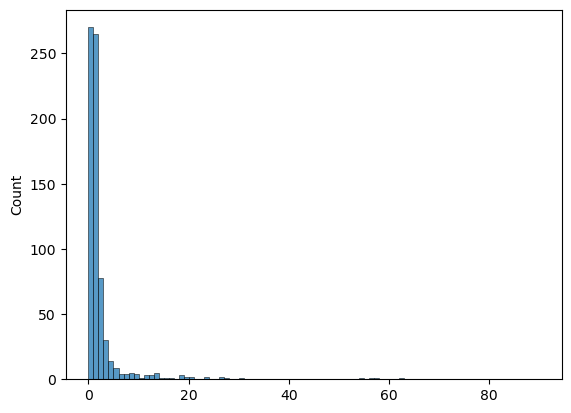

In [34]:
sns.histplot(out_degree_values,bins=range(out_degree_max))

In [35]:
G.edges("ZNF441")

OutEdgeDataView([('ZNF441', 'UBAC1'), ('ZNF441', 'MRPS12'), ('ZNF441', 'SMIM20'), ('ZNF441', 'PARG'), ('ZNF441', 'FBL'), ('ZNF441', 'CLDND1'), ('ZNF441', 'CPVL'), ('ZNF441', 'ANAPC13'), ('ZNF441', 'SNX24'), ('ZNF441', 'MRPL2'), ('ZNF441', 'MAPKAPK5'), ('ZNF441', 'SOX11')])

### Apply reverse Page rank

In [36]:
up_edges =   [(u, v) for u, v, attributes in G.edges(data=True) 
              if attributes.get('regulation') == 'up_regualte']
down_edges = [(u, v) for u, v, attributes in G.edges(data=True) 
              if attributes.get('regulation') == 'down_regualte']

In [37]:
G_up   = G.edge_subgraph(up_edges)
G_down = G.edge_subgraph(down_edges)

In [38]:
print(len(list(G_down.nodes)))
print(len(list(G_up.nodes)))

3370
7874


In [39]:
weight_dict = {}
for node in G.nodes():
    if (node in CHD_gene_name) and (not node in TF_nodes):
        print
        weight_dict[node] = 1.0
    else:
        weight_dict[node] = 0.0

# Normalization
total = sum(weight_dict.values())
if total > 0:
    for node in weight_dict:
        weight_dict[node] /= total

In [40]:
weight_dict["TBX20"]

0.0

In [41]:
reversed_G = G.reverse(copy=True)
pr_res_total = nx.pagerank(reversed_G,alpha=0.85,personalization=weight_dict)
pr_res_df_total = pd.DataFrame(pr_res_total.values(),index=pr_res_total.keys(),columns=["importance"])
pr_res_df_total = pr_res_df_total.sort_values("importance",ascending=False)

In [42]:
pr_res_df_total.head(20)

,importance
ISL1,0.029494
SOX11,0.019758
TBX20,0.018863
ARNT,0.017340
ZNF441,0.016752
NKX2-5,0.015038
ZFPM2,0.014896
TADA2B,0.014752
RCOR2,0.013033
ZFPM1,0.012532


In [43]:
pr_res_df_total.loc["TBX5"]

importance    0.000219
Name: TBX5, dtype: float64

In [44]:
pr_res_df_total.index[:20]

Index(['ISL1', 'SOX11', 'TBX20', 'ARNT', 'ZNF441', 'NKX2-5', 'ZFPM2', 'TADA2B',
       'RCOR2', 'ZFPM1', 'ARID2', 'SOX4', 'CRAMP1L', 'PITX2', 'PLAGL2',
       'HAND1', 'ZFP90', 'HOXB4', 'SMAD5', 'LCOR'],
      dtype='object')

#### Only focus on upregulation

In [45]:
reversed_G_up = G_up.reverse(copy=True)
pr_res_up = nx.pagerank(reversed_G_up,alpha=0.85,personalization=weight_dict)
pr_res_df_up = pd.DataFrame(pr_res_up.values(),index=pr_res_up.keys(),columns=["importance"])
pr_res_df_up = pr_res_df_up.sort_values("importance",ascending=False)

In [46]:
pr_res_df_up.head(10)

,importance
ISL1,0.028448
SOX11,0.019147
ARNT,0.018346
ZFPM2,0.016800
ZNF441,0.016357
ZFPM1,0.014380
TADA2B,0.014129
RCOR2,0.013677
ARID2,0.012136
TBX20,0.011349


#### Only focus on downregulation

In [47]:
reversed_G_down = G_down.reverse(copy=True)
pr_res_down = nx.pagerank(reversed_G_down,alpha=0.85,personalization=weight_dict)
pr_res_df_down = pd.DataFrame(pr_res_down.values(),index=pr_res_down.keys(),columns=["importance"])
pr_res_df_down = pr_res_df_down.sort_values("importance",ascending=False)

In [48]:
pr_res_df_down.head(10)

,importance
TBX20,0.106423
HOXB4,0.081092
SOX11,0.045186
NKX2-5,0.035481
ARID3A,0.030101
MEF2C,0.024362
RERE,0.021028
MYH7,0.021028
RBFOX2,0.021028
TAB2,0.021028


#### plot pagerank feature

In [49]:
pr_res_df_total_TF = pr_res_df_total[np.isin(pr_res_df_total.index,TF_nodes)]

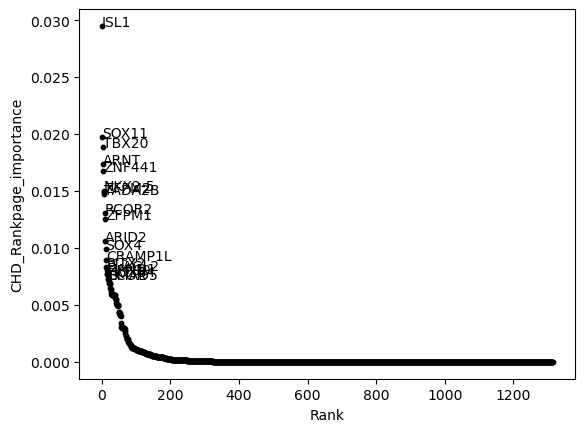

In [50]:
rank = list(range(pr_res_df_total_TF.shape[0]))
value = pr_res_df_total_TF["importance"].values
plt.scatter(rank,value,s=10,c="black",marker="o")
plt.xlabel("Rank")
plt.ylabel("CHD_Rankpage_importance")

for i in range(20):
    plt.text(rank[i],value[i],pr_res_df_total.index[i])
    
plt.savefig("Plot/CHD_pagerank_importance.pdf")

In [51]:
print(len(G.nodes))
print(len(G.edges))

8438
25621


### CHD regulator TF_enrichment

In [52]:
NonTF_CHD_genes = set(CHD_genes_df['Gene']).difference(set(TF_region_df['TF'].values))

In [53]:
regulator_dict = {}
count_dict = {}

for gene in NonTF_CHD_genes:
    if gene in G.nodes():
        regulator = np.unique(list(G.predecessors(gene)))
        regulator_dict[gene] = regulator
        count_dict[gene] = len(regulator)

In [54]:
G["AHCY"]["H19"]

{'regulation': 'up_regualte'}

In [55]:
all_regulator = np.unique(np.concatenate(list(regulator_dict.values())))

downstream_CHD_dict = {}
downstream_CHD_count_dict = {}

for tf in all_regulator:
    downstream_CHD_dict[tf] = {"up":[],
                               "down":[]}
    
    ds_gene = list(G.successors(tf))
    ds_gene = list(set(ds_gene) & set(CHD_genes_df['Gene']))
    for gene in ds_gene:
        if G[tf][gene]["regulation"]=="up_regualte":
            downstream_CHD_dict[tf]["up"].append(gene)
        else:
            downstream_CHD_dict[tf]["down"].append(gene)
    downstream_CHD_count_dict[tf] = {"total":[],"up":[],"down":[]}
    downstream_CHD_count_dict[tf]["up"] = len(downstream_CHD_dict[tf]["up"])
    downstream_CHD_count_dict[tf]["down"] = len(downstream_CHD_dict[tf]["down"])
    downstream_CHD_count_dict[tf]["total"] = downstream_CHD_count_dict[tf]["up"] + \
                                             downstream_CHD_count_dict[tf]["down"]

In [56]:
downstream_CHD_df = pd.DataFrame(downstream_CHD_count_dict).T

In [57]:
downstream_CHD_df = downstream_CHD_df.sort_values("total",ascending=False)

In [58]:
top20_chd_regulating_tf = list(downstream_CHD_df.index[:20])

In [59]:
top20_chd_regulating_tf

['ISL1',
 'TBX20',
 'SOX11',
 'RCOR2',
 'NKX2-5',
 'SMAD5',
 'HOXB4',
 'TADA2B',
 'HAND1',
 'PITX2',
 'ZFPM2',
 'SMAD6',
 'MEF2C',
 'ARID2',
 'MEIS1',
 'SOX4',
 'TCF7',
 'ZBTB10',
 'ZNF532',
 'ZNF20']

In [60]:
set(top20_chd_regulating_tf) & set(CHD_genes_df['Gene'])

{'HAND1', 'NKX2-5', 'PITX2', 'SMAD6', 'TBX20', 'ZFPM2'}

In [61]:
downstream_CHD_df_melt=downstream_CHD_df.head(20).melt(ignore_index=False).reset_index()

In [62]:
downstream_CHD_df_melt.head()

,index,variable,value
0,ISL1,total,20
1,TBX20,total,18
2,SOX11,total,15
3,RCOR2,total,14
4,NKX2-5,total,12


In [63]:
count_df = pd.DataFrame(count_dict.values(),index=count_dict.keys(),columns=["count"])
count_df = count_df.sort_values("count",ascending=False)

In [85]:
print(count_df.shape)
print(np.mean(count_df))

(50, 1)
7.36


In [64]:
count_df_sub = count_df.head(10)

In [86]:
count_df_sub

,count
MYH7,71
MYH6,51
KDR,46
ACTC1,42
GPC3,27
MYBPC3,21
FBN1,9
CITED2,9
TAB2,7
GJA1,6


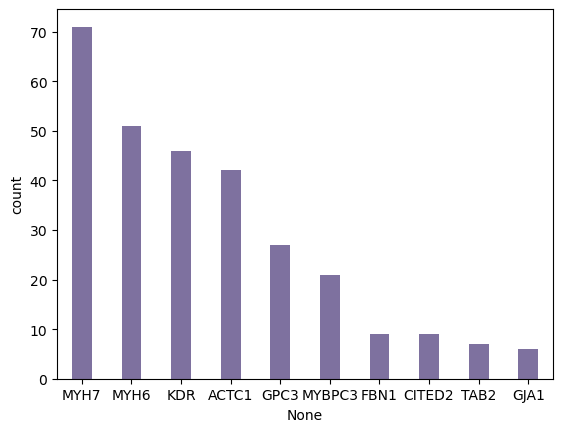

In [65]:
sns.barplot(x=count_df_sub.index,y=count_df_sub["count"],color="#7B69A7",width=0.4)
plt.savefig("./Plot/CHD_regulated_num.pdf")

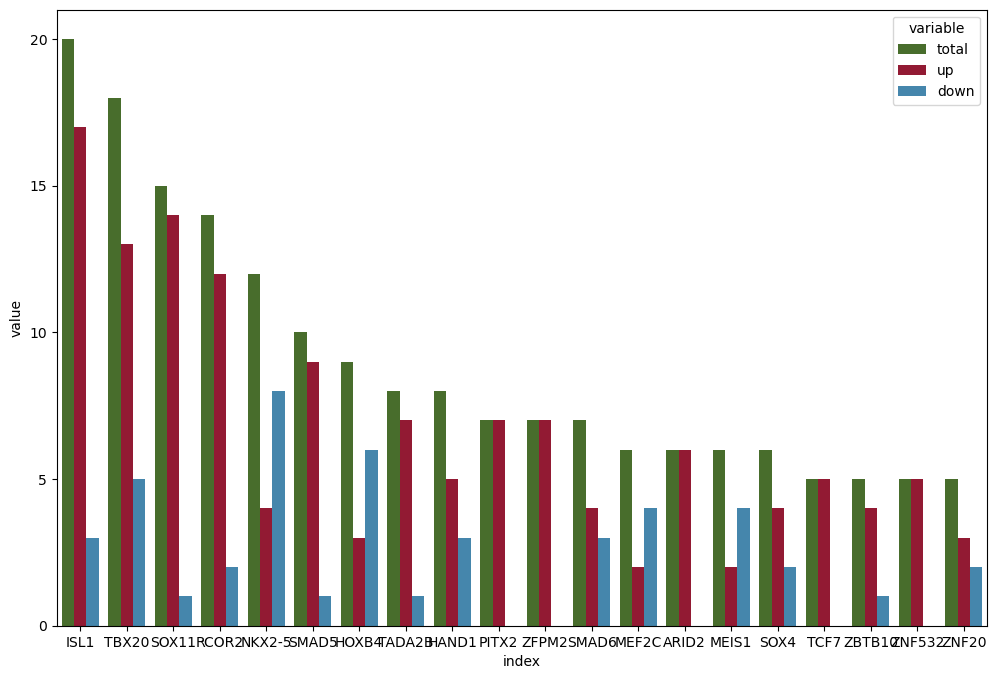

In [66]:
barWidth = 0.25
fig,ax = plt.subplots(figsize =(12, 8)) 
sns.barplot(downstream_CHD_df_melt,
            x="index",y="value",hue="variable",color="#7B69A7",width=0.8,
            palette=["#467821","#A60628","#348ABD"]
           )
plt.yticks([0,5,10,15,20])

plt.savefig("./Plot/CHD_DE_num.pdf")

In [87]:
downstream_CHD_df

,total,up,down
ISL1,20,17,3
TBX20,18,13,5
SOX11,15,14,1
RCOR2,14,12,2
NKX2-5,12,4,8
...,...,...,...
BBX,1,0,1
BHLHA15,1,1,0
BNC1,1,1,0
CAMTA2,1,1,0


### Num of CHD gene regulate

### Visualize TF-network

In [67]:
NonTF_CHD_genes = set(CHD_genes_df['Gene']).difference(set(TF_region_df['TF'].values))

In [68]:
print(len(NonTF_CHD_genes))

92


In [69]:
TF_motif_file = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/TF_motif/NonTFCHD_gene_TFmotif.txt'
TF_motif = pd.read_csv(TF_motif_file, sep='\t', names=['rechr', 'restart', 'reend', 'gene', 'chr', 'start', 'end', 'motif', 'pos', 'strand', 'TF', 'overlap'])

In [70]:
bindings = np.array([(a, b) for a, b in zip(TF_motif['TF'], TF_motif['gene'])])

In [71]:
len(bindings)

301985

In [72]:
bindings

array([['ZNF184', 'SMC3'],
       ['Pparg::Rxra', 'SMC3'],
       ['Pparg::Rxra', 'SMC3'],
       ...,
       ['NR1I3', 'HDAC8'],
       ['Nr2e1', 'HDAC8'],
       ['NR2F1', 'HDAC8']], dtype='<U14')

In [73]:
motif_dict = {}
keys = np.unique(bindings[:,0])
for key in keys:
    key_upper = key.upper()
    motif_genes = np.unique(bindings[bindings[:,0]==key][:,1])
    motif_dict[key_upper] = motif_genes

In [74]:
for u, v in G.edges():
    if u in motif_dict.keys():
        if v in motif_dict[u]:
            G[u][v]["weight"]=3
        else:
            G[u][v]["weight"]=1
    else:
        G[u][v]["weight"]=1

#### extract non-TF CHD + regulator

In [75]:
node_list = []
for gene in NonTF_CHD_genes:
    if gene in G.nodes():
        node_list.append([gene])
        node_list.append(list(G.predecessors(gene)))

node_list = np.unique(np.concatenate(node_list))

In [76]:
len(node_list)

260

In [77]:
G_non_tf_chd = G.subgraph(node_list).copy()

In [78]:
TF_nodes_chd = [node for node, data in G_non_tf_chd.nodes(data=True) if data.get("type") == "TF"]
gene_nodes_chd = [node for node, data in G_non_tf_chd.nodes(data=True) if data.get("type") == "gene"]

print(len(TF_nodes_chd))
print(len(gene_nodes_chd))

210
50


In [79]:
CHD_TF_nodes = []
TF_nodes = []
non_TF_CHD_nodes = []

for node_name,attr in G_non_tf_chd.nodes(data=True):
    if attr["type"]=="gene":
        non_TF_CHD_nodes.append(node_name)
    else:
        if node_name in CHD_genes_df['Gene'].values:
            CHD_TF_nodes.append(node_name)
        else:
            TF_nodes.append(node_name)

In [80]:
pos = nx.kamada_kawai_layout(G_non_tf_chd, weight=100, scale=1000)

/tmp/ipykernel_51880/1580508155.py:28: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G_non_tf_chd, pos,
/tmp/ipykernel_51880/1580508155.py:32: DeprecationWarning: `alltrue` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `all` instead.
  nx.draw_networkx_edges(G_non_tf_chd, pos,


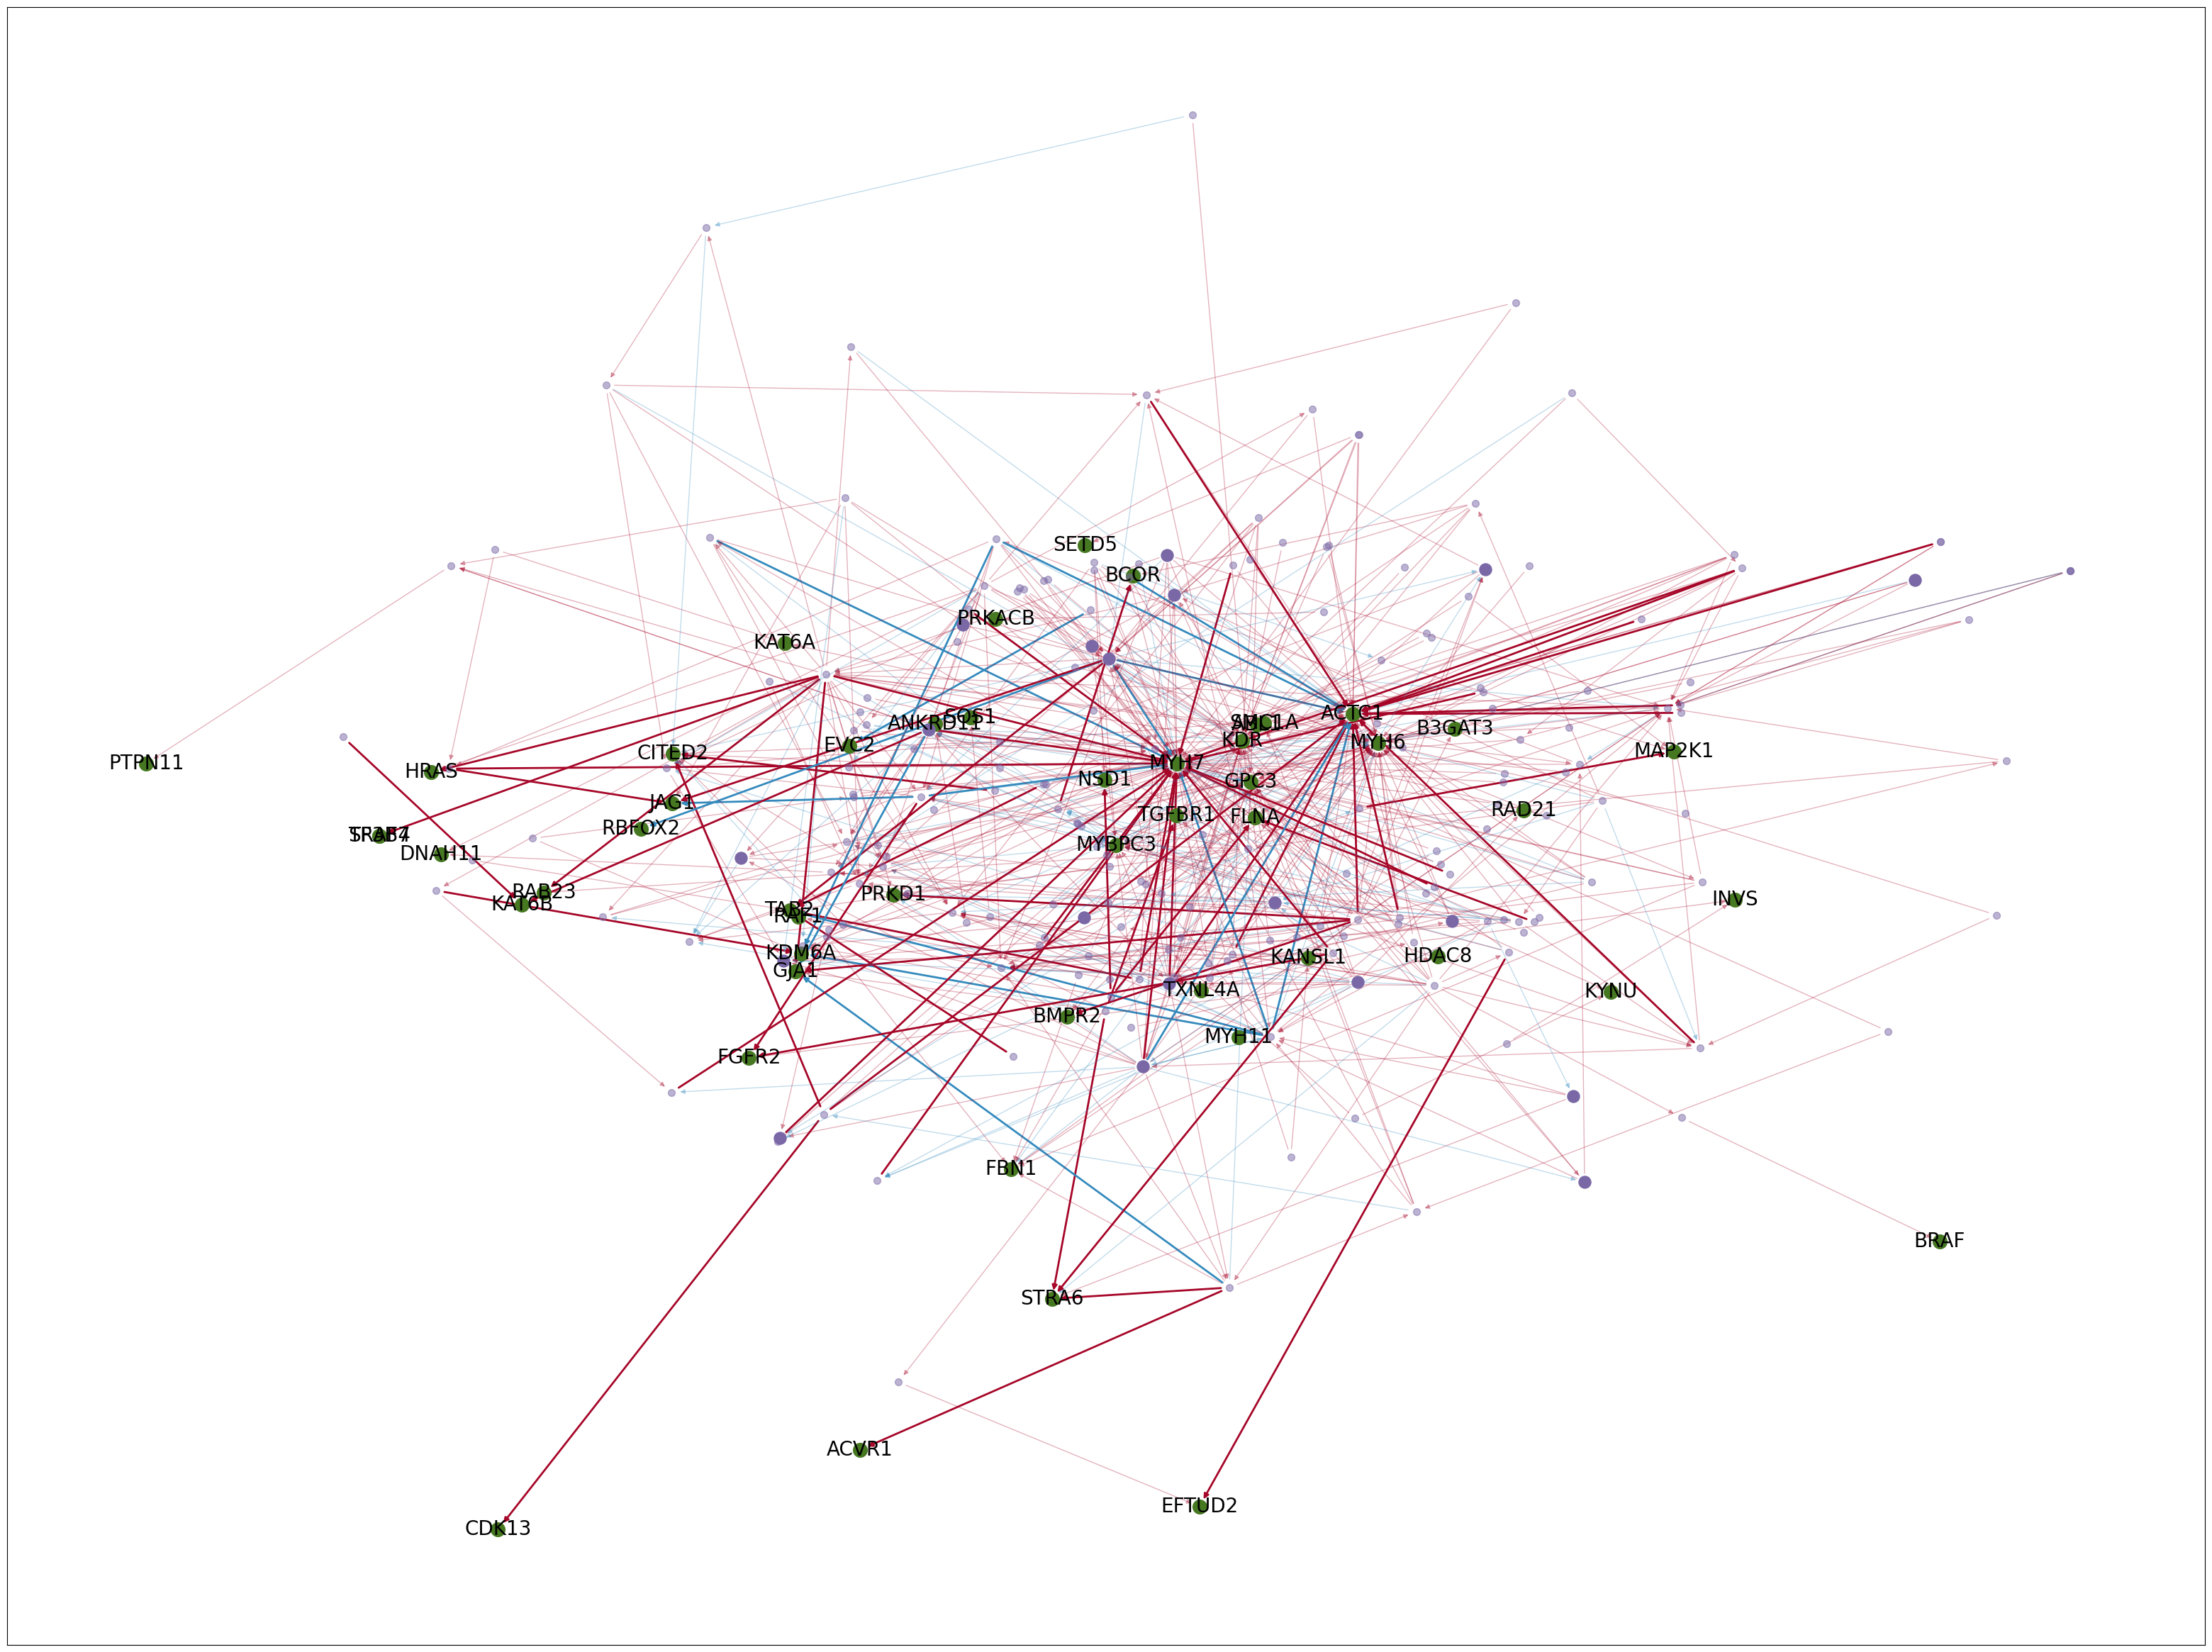

In [81]:
fig, ax = plt.subplots(figsize= (40,30))

nx.draw_networkx_nodes(G_non_tf_chd, pos,
                       nodelist = non_TF_CHD_nodes,
                       node_shape = 'o',
                       node_size=200, 
                       node_color='#467821', 
                       alpha=1)

nx.draw_networkx_nodes(G_non_tf_chd, pos,
                       nodelist = CHD_TF_nodes,
                       node_shape = 'o',
                       node_size=150, 
                       node_color='#7A68A6', 
                       alpha=1)

nx.draw_networkx_nodes(G_non_tf_chd, pos,
                       nodelist = TF_nodes,
                       node_shape = 'o',
                       node_size=50, 
                       node_color='#7A68A6',
                       alpha=0.5)

labels = {node: str(node) for node in non_TF_CHD_nodes}
nx.draw_networkx_labels(G_non_tf_chd, pos, labels, font_size=20)

for i in G_non_tf_chd.nodes():
    nx.draw_networkx_edges(G_non_tf_chd, pos,
                           edgelist=[(u,v) for u,v,e in G_non_tf_chd.edges(i, data=True)
                                     if e['regulation']=='down_regualte'],
                           edge_color='#348ABD', alpha=0.3)
    nx.draw_networkx_edges(G_non_tf_chd, pos,
                           edgelist=[(u,v) for u,v,e in G_non_tf_chd.edges(i, data=True)
                                     if e['regulation']=='up_regualte'],
                           edge_color='#A60628', alpha=0.3)
    
    nx.draw_networkx_edges(G_non_tf_chd, pos, 
                           edgelist=[(u,v) for u,v,e in G_non_tf_chd.edges(i, data=True) 
                                     if ((e['regulation']=='down_regualte') & (e['weight'] == 3))],
                           edge_color='#348ABD', alpha=1, width=2)
    nx.draw_networkx_edges(G_non_tf_chd, pos, 
                           edgelist=[(u,v) for u,v,e in G_non_tf_chd.edges(i, data=True)
                                     if ((e['regulation']=='up_regualte') & (e['weight'] == 3))],
                           edge_color='#A60628', alpha=1, width=2)